In [ ]:
myFavoriteNumber = 1984

In [ ]:
#pip install kagglehub

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsRegressor

get our dataset

In [ ]:
import kagglehub
from kagglehub import KaggleDatasetAdapter

#student-exam-performance-dataset-analysis
#StudentPerformanceFactors.csv

df = kagglehub.dataset_load(
  KaggleDatasetAdapter.PANDAS,
  "jimarahman/student-exam-performance-dataset-analysis",
  "StudentPerformanceFactors.csv",
)

Using Colab cache for faster access to the 'student-exam-performance-dataset-analysis' dataset.


split into x and y. Using all features because they genuinely all look significant

In [ ]:
X = df.drop(['Exam_Score'], axis=1)
y = df["Exam_Score"]

In [ ]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 19 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   Hours_Studied               6607 non-null   int64 
 1   Attendance                  6607 non-null   int64 
 2   Parental_Involvement        6607 non-null   object
 3   Access_to_Resources         6607 non-null   object
 4   Extracurricular_Activities  6607 non-null   object
 5   Sleep_Hours                 6607 non-null   int64 
 6   Previous_Scores             6607 non-null   int64 
 7   Motivation_Level            6607 non-null   object
 8   Internet_Access             6607 non-null   object
 9   Tutoring_Sessions           6607 non-null   int64 
 10  Family_Income               6607 non-null   object
 11  Teacher_Quality             6529 non-null   object
 12  School_Type                 6607 non-null   object
 13  Peer_Influence              6607 non-null   obje

Because we're using many models, I'm going to make each model as a pipeline instead of doing it much more manually each time. To do this...
First we need to get which columns are integers and which are categorical. Some (most??) models will get scaling and more importantly some models will get one-hot-encoded while some will remain in their categories.

In [ ]:
num_cols = X.select_dtypes(include=["int64"]).columns
obj_cols = X.select_dtypes(include=["object"]).columns
#X[obj_cols] = X[obj_cols].astype(str)
#X[num_cols] = X[num_cols].astype(float)

Obviously, split data as well.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size = 0.3, random_state = myFavoriteNumber)

Correlation between numerical features

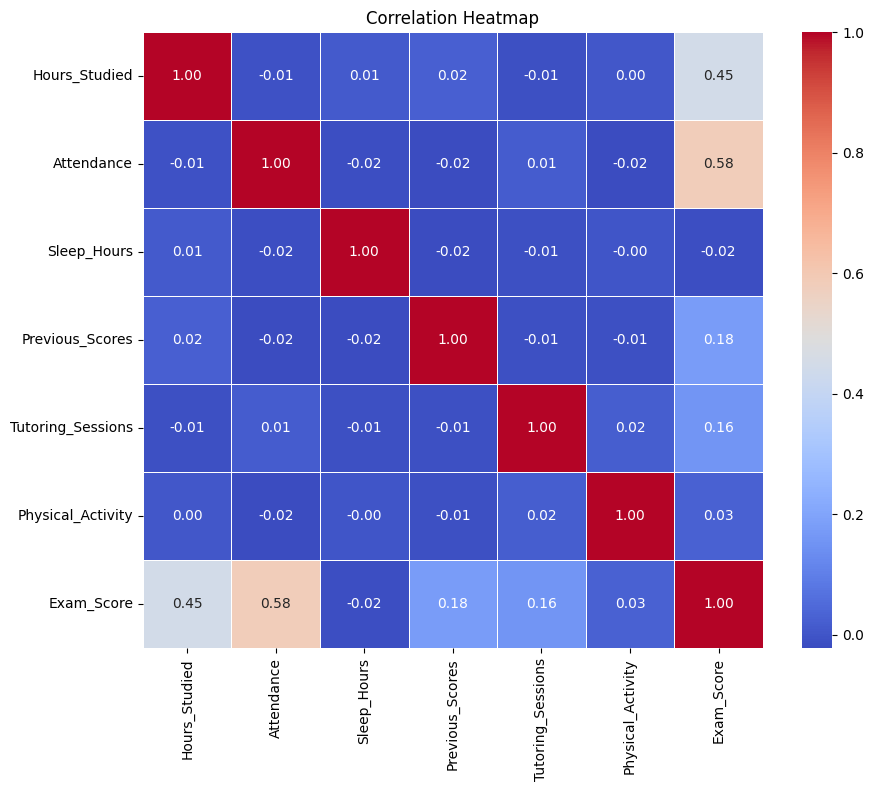

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Select only numeric columns (correlation only works on numbers)
numeric_df = df.select_dtypes(include=['number'])

# Compute correlation matrix
corr_matrix = numeric_df.corr()

# Plot heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)

plt.title("Correlation Heatmap")
plt.show()

Conditional Entropy for categorical features

In [ ]:
import pandas as pd
import numpy as np
from scipy.stats import entropy

# Bin exam score into e.g. quartiles
df['Exam_Score_binned'] = pd.qcut(df['Exam_Score'], q=4, labels=['Q1','Q2','Q3','Q4'])

In [ ]:
def conditional_entropy(feature_col, target_col, df):
    """H(Y | X) = sum_x P(X=x) * H(Y | X=x)"""
    total = len(df)
    h_y_given_x = 0.0

    for val in df[feature_col].unique():
        subset = df[df[feature_col] == val]
        p_x = len(subset) / total
        # value counts of target within this subset
        counts = subset[target_col].value_counts()
        probs = counts / counts.sum()
        h_y_given_x += p_x * entropy(probs, base=2)

    return h_y_given_x

In [ ]:
obj_cols = X.select_dtypes(include=["object"]).columns

results = {}
for col in obj_cols:
    h = conditional_entropy(col, 'Exam_Score_binned', df)
    results[col] = h

# Also compute marginal entropy of target for reference
target_counts = df['Exam_Score_binned'].value_counts()
h_y = entropy(target_counts / target_counts.sum(), base=2)
print(f"H(Y) marginal entropy: {h_y:.4f} bits\n")

# Information gain = H(Y) - H(Y|X)
results_df = pd.DataFrame.from_dict(results, orient='index', columns=['H(Y|X)'])
results_df['Information_Gain'] = h_y - results_df['H(Y|X)']
results_df['IG_Ratio'] = results_df['Information_Gain'] / h_y  # normalized 0–1
results_df = results_df.sort_values('Information_Gain', ascending=False)
print(results_df)

H(Y) marginal entropy: 1.9787 bits

                              H(Y|X)  Information_Gain  IG_Ratio
Access_to_Resources         1.954731          0.023950  0.012104
Parental_Involvement        1.960795          0.017886  0.009039
Peer_Influence              1.969415          0.009266  0.004683
Family_Income               1.971927          0.006754  0.003413
Motivation_Level            1.971965          0.006716  0.003394
Learning_Disabilities       1.973044          0.005638  0.002849
Extracurricular_Activities  1.975536          0.003146  0.001590
Internet_Access             1.976212          0.002469  0.001248
School_Type                 1.978537          0.000144  0.000073
Gender                      1.978610          0.000072  0.000036
Teacher_Quality                  NaN               NaN       NaN
Parental_Education_Level         NaN               NaN       NaN
Distance_from_Home               NaN               NaN       NaN


Knn first. Standard scaling and one hot encoding

In [ ]:
knn_preprocess = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("obj", OneHotEncoder(handle_unknown="ignore"), obj_cols)
    ]
)

knn_model = Pipeline(steps=[
    ("preprocess", knn_preprocess),
    ("knn", KNeighborsRegressor(n_neighbors=5))
])

Fit and test model

In [ ]:
knn_model.fit(X_train, y_train)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  Index(['Hours_Studied', 'Attendance', 'Sleep_Hours', 'Previous_Scores',
       'Tutoring_Sessions', 'Physical_Activity'],
      dtype='object')),
                                                 ('obj',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  Index(['Parental_Involvement', 'Access_to_Resources',
       'Extracurricular_Activities', 'Motivation_Level', 'Internet_Access',
       'Family_Income', 'Teacher_Quality', 'School_Type', 'Peer_Influence',
       'Learning_Disabilities', 'Parental_Education_Level',
       'Distance_from_Home', 'Gender'],
      dtype='object'))])),
                ('knn', KNeighborsRegressor())])

In [ ]:
#score = knn_model.score(X_test, y_test)
#print("KNN accuracy:", score)

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

y_pred = knn_model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2:", r2)


MAE: 1.535451336359052
RMSE: 2.649983111108039
R2: 0.5135793236488211


Lmfao that's bad but makes sense. We have like a million features and any of them could be important.

Naive Bayes next. I'm using Gaussian because that's what ai tells me is best for mostly continuous and categorical values. No scaling. One hot encoding

NOTE: THIS DOES NOT WORK AT ALL ACTUALLY. I HAD TO REFACTOR THINGS TO BE REGRESSORS INSTEAD OF CLASSIFIERS. NAIVE BAYES DOES NOT DO THIS

In [ ]:
from sklearn.naive_bayes import GaussianNB

In [ ]:
NB_preprocess = ColumnTransformer(
    transformers=[
        ("num", "passthrough", num_cols),
        ("obj", OneHotEncoder(handle_unknown="ignore"), obj_cols)
    ]
)

NB_model = Pipeline(steps=[
    ("preprocess", NB_preprocess),
    ("NB", GaussianNB())
])

In [ ]:
NB_model.fit(X_train, y_train)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num', 'passthrough',
                                                  Index(['Hours_Studied', 'Attendance', 'Sleep_Hours', 'Previous_Scores',
       'Tutoring_Sessions', 'Physical_Activity'],
      dtype='object')),
                                                 ('obj',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  Index(['Parental_Involvement', 'Access_to_Resources',
       'Extracurricular_Activities', 'Motivation_Level', 'Internet_Access',
       'Family_Income', 'Teacher_Quality', 'School_Type', 'Peer_Influence',
       'Learning_Disabilities', 'Parental_Education_Level',
       'Distance_from_Home', 'Gender'],
      dtype='object'))])),
                ('NB', GaussianNB())])

score = NB_model.score(X_test, y_test)
print("NB accuracy:", score)

LMFAOOO

Decision tree next. This one I expect to actually do better than random guessing. Random forest should be really good.
Standard scaling. One hot encoding

In [ ]:
from sklearn.tree import DecisionTreeRegressor

In [ ]:
DT_preprocess = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("obj", OneHotEncoder(handle_unknown="ignore"), obj_cols)
    ]
)

DT_model = Pipeline(steps=[
    ("preprocess", DT_preprocess),
    ("NB", DecisionTreeRegressor(random_state=myFavoriteNumber, max_depth=5, min_samples_leaf=3, min_samples_split=3, max_features=0.5))
])

In [ ]:
DT_model.fit(X_train, y_train)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  Index(['Hours_Studied', 'Attendance', 'Sleep_Hours', 'Previous_Scores',
       'Tutoring_Sessions', 'Physical_Activity'],
      dtype='object')),
                                                 ('obj',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  Index(['Parental_Involvement', 'Access_to_Resources',
       'Extracurricular_Activities', 'Motivation_Level', 'Internet_Access',
       'Family_Income', 'Teacher_Quality', 'School_Type', 'Peer_Influence',
       'Learning_Disabilities', 'Parental_Education_Level',
       'Distance_from_Home', 'Gender'],
      dtype='object'))])),
                ('NB',
                 DecisionTreeRegressor(max_depth=5, max_features=0.5,
                                       min_samples_leaf=3, min_samples_split=3,
                                       random_state=1984))])

In [ ]:
y_pred = DT_model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2:", r2)

MAE: 1.7304248372827837
RMSE: 2.7439133386161134
R2: 0.4784852491184648


I'm fucking with the values and can't get anything higher than 20% accuracy. Very surprising. I'll make it into a grid search later to find the best.

Random Forest next. I have high hopes for this one.
Standard Scaler. One hot encoding

In [ ]:
from sklearn.ensemble import RandomForestRegressor

In [ ]:
RF_preprocess = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("obj", OneHotEncoder(handle_unknown="ignore"), obj_cols)
    ]
)

RF_model = Pipeline(steps=[
    ("preprocess", DT_preprocess),
    ("NB", RandomForestRegressor(
        n_estimators=100,
        random_state=myFavoriteNumber,
        n_jobs=-1
    ))
])

In [ ]:
RF_model.fit(X_train, y_train)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  Index(['Hours_Studied', 'Attendance', 'Sleep_Hours', 'Previous_Scores',
       'Tutoring_Sessions', 'Physical_Activity'],
      dtype='object')),
                                                 ('obj',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  Index(['Parental_Involvement', 'Access_to_Resources',
       'Extracurricular_Activities', 'Motivation_Level', 'Internet_Access',
       'Family_Income', 'Teacher_Quality', 'School_Type', 'Peer_Influence',
       'Learning_Disabilities', 'Parental_Education_Level',
       'Distance_from_Home', 'Gender'],
      dtype='object'))])),
                ('NB', RandomForestRegressor(n_jobs=-1, random_state=1984))])

In [ ]:
#score = RF_model.score(X_test, y_test)
#print("RF accuracy:", score)

y_pred = RF_model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2:", r2)

MAE: 1.106490166414523
RMSE: 2.272102700316754
R2: 0.6424129925678828


This dataset sucks ass. If RF ain't doing it, when we're going to have to do more preprocessing on these features. Disappointing: I really thought we'd get to use them all.

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers
# Numeric preprocessing
numeric_inputs = {}
for col in num_cols:
    numeric_inputs[col] = tf.keras.Input(shape=(1,), name=col)
    norm_layer = layers.Normalization()
    # adapt learns mean/std
    norm_layer.adapt(X[col].values)
    numeric_inputs[col] = norm_layer(numeric_inputs[col])

# Categorical preprocessing
categorical_inputs = {}
for col in obj_cols:
    categorical_inputs[col] = tf.keras.Input(shape=(1,), dtype=tf.string, name=col)
    lookup = layers.StringLookup(output_mode="one_hot")
    lookup.adapt(X[col].values)
    categorical_inputs[col] = lookup(categorical_inputs[col])


ValueError: Failed to convert a NumPy array to a Tensor (Unsupported object type float).

In [ ]:
ANN_preprocess = ColumnTransformer([
    ("num", StandardScaler(), num_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore"), obj_cols)
])

X_train_tf = ANN_preprocess.fit_transform(X_train)
X_test_tf = ANN_preprocess.transform(X_test)


In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.optimizers import Adam


In [ ]:
model = Sequential()
model.add(Input(shape=(X_train_tf.shape[1],)))
model.add(Dense(64, activation='relu'))
model.add(Dropout(0.1))
model.add(Dense(32, activation='relu'))
model.add(Dropout(0.1))
model.add(Dense(1, activation='linear'))  # regression output

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='mse',
    metrics=['mae']
)


In [ ]:
model.fit(X_train_tf, y_train, epochs=50, batch_size=8)


In [ ]:
import numpy as np
# Evaluate model
mse, mae = model.evaluate(X_test_tf, y_test, verbose=0)
rmse = np.sqrt(mse)

print("MSE:", mse)
print("MAE:", mae)
print("RMSE:", rmse)

# R2 score
from sklearn.metrics import r2_score
y_pred = model.predict(X_test_tf)
print("R2 Score:", r2_score(y_test, y_pred))


In [ ]:
print (y_pred)

In [ ]:
print(y_test)

wowza neural networks are insane. MAE 1.19 we're 1.19% off on average per guess!!!